In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

np.random.seed(42)

Part 1


In [2]:
N = 3000

x1 = np.random.uniform(-2, 2, N)
x2 = np.random.uniform(-2, 2, N)

X = np.column_stack((x1, x2))
y = ((x1**2 + x2**2) > 1.5).astype(int).reshape(-1,1)

In [3]:
idx = np.random.permutation(N)

t1 = int(0.7*N)
t2 = int(0.85*N)

train_idx = idx[:t1]
val_idx = idx[t1:t2]
test_idx = idx[t2:]

X_train, y_train = X[train_idx], y[train_idx]
X_val, y_val = X[val_idx], y[val_idx]
X_test, y_test = X[test_idx], y[test_idx]

In [4]:
def sigmoid(z):
    return 1/(1+np.exp(-z))

def dsigmoid(z):
    s = sigmoid(z)
    return s*(1-s)

def relu(z):
    return np.maximum(0,z)

def drelu(z):
    return (z>0).astype(float)

In [5]:
def init_params(layers):
    params = {}
    for i in range(1,len(layers)):
        params[f"W{i}"] = np.random.randn(layers[i-1], layers[i])*0.1
        params[f"b{i}"] = np.zeros((1,layers[i]))
    return params

In [6]:
def forward(X, params, act):
    cache = {}
    A = X
    L = len(params)//2

    for i in range(1,L):
        Z = A @ params[f"W{i}"] + params[f"b{i}"]
        cache[f"Z{i}"] = Z
        A = relu(Z) if act=="relu" else sigmoid(Z)
        cache[f"A{i}"] = A

    ZL = A @ params[f"W{L}"] + params[f"b{L}"]
    AL = sigmoid(ZL)

    cache[f"Z{L}"] = ZL
    cache[f"A{L}"] = AL

    return AL, cache

In [7]:
def loss_fn(y, y_hat):
    eps = 1e-8
    y_hat = np.clip(y_hat, eps, 1-eps)
    return -np.mean(y*np.log(y_hat)+(1-y)*np.log(1-y_hat))

def acc_fn(y, y_hat):
    return np.mean((y_hat>=0.5)==y)

In [8]:
def backward(X, y, params, cache, act):
    grads = {}
    m = len(y)
    L = len(params)//2

    dZ = cache[f"A{L}"] - y

    for i in reversed(range(1,L+1)):
        A_prev = X if i==1 else cache[f"A{i-1}"]

        grads[f"dW{i}"] = (A_prev.T @ dZ)/m
        grads[f"db{i}"] = np.sum(dZ,axis=0,keepdims=True)/m

        if i>1:
            dA = dZ @ params[f"W{i}"].T
            Z_prev = cache[f"Z{i-1}"]
            dZ = dA * (drelu(Z_prev) if act=="relu" else dsigmoid(Z_prev))

    return grads

In [11]:
def sgd(params, grads, lr):
    L = len(params)//2
    for i in range(1,L+1):
        params[f"W{i}"] -= lr*grads[f"dW{i}"]
        params[f"b{i}"] -= lr*grads[f"db{i}"]
    return params

def momentum(params, grads, v, lr, beta=0.9):
    L = len(params)//2
    for i in range(1,L+1):
        if f"dW{i}" not in v:
            v[f"dW{i}"] = np.zeros_like(grads[f"dW{i}"])
            v[f"db{i}"] = np.zeros_like(grads[f"db{i}"])

        v[f"dW{i}"] = beta*v[f"dW{i}"] + (1-beta)*grads[f"dW{i}"]
        v[f"db{i}"] = beta*v[f"db{i}"] + (1-beta)*grads[f"db{i}"]

        params[f"W{i}"] -= lr*v[f"dW{i}"]
        params[f"b{i}"] -= lr*v[f"db{i}"]

    return params, v

In [12]:
def train_model(layers, act="relu", opt="sgd", epochs=200, lr=0.01):

    params = init_params(layers)
    v = {}

    tr_loss, val_loss = [], []
    tr_acc, val_acc = [], []

    for e in range(epochs):

        y_hat, cache = forward(X_train, params, act)
        loss = loss_fn(y_train, y_hat)
        acc = acc_fn(y_train, y_hat)

        grads = backward(X_train, y_train, params, cache, act)

        if opt=="sgd":
            params = sgd(params, grads, lr)
        else:
            params, v = momentum(params, grads, v, lr)

        val_hat,_ = forward(X_val, params, act)

        tr_loss.append(loss)
        val_loss.append(loss_fn(y_val,val_hat))
        tr_acc.append(acc)
        val_acc.append(acc_fn(y_val,val_hat))

    test_hat,_ = forward(X_test, params, act)

    return {
        "params":params,
        "train_loss":tr_loss,
        "val_loss":val_loss,
        "train_acc":tr_acc,
        "val_acc":val_acc,
        "test_loss":loss_fn(y_test,test_hat),
        "test_acc":acc_fn(y_test,test_hat)
    }

In [13]:
architectures = {
    "2-layer":[2,8,1],
    "5-layer":[2,8,8,8,8,1],
    "10-layer":[2]+[8]*8+[1]
}


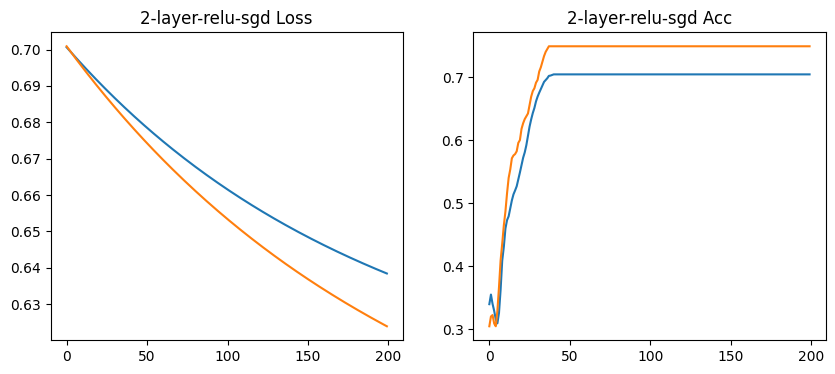

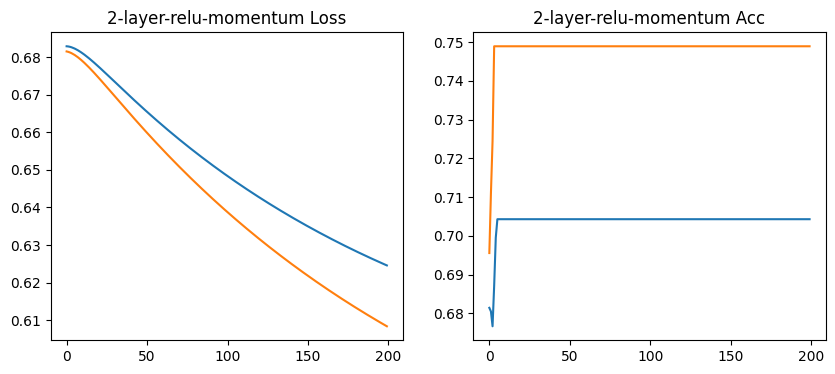

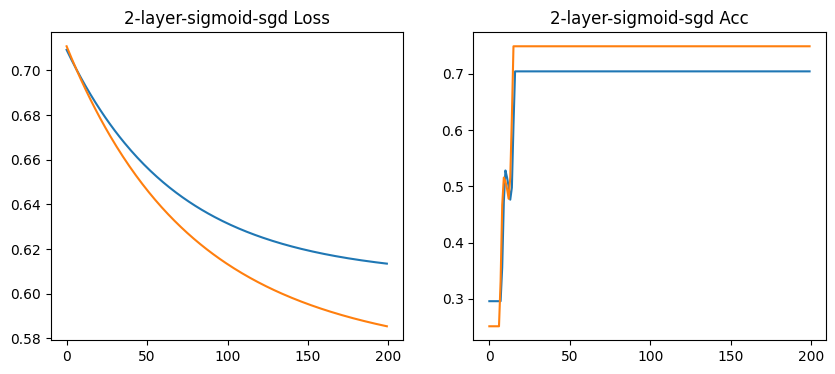

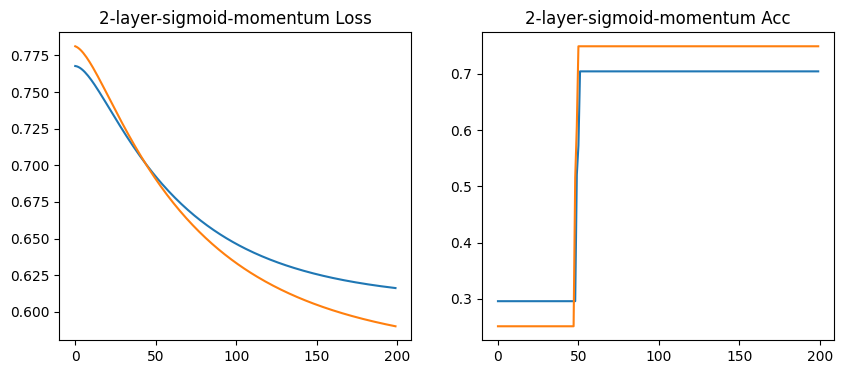

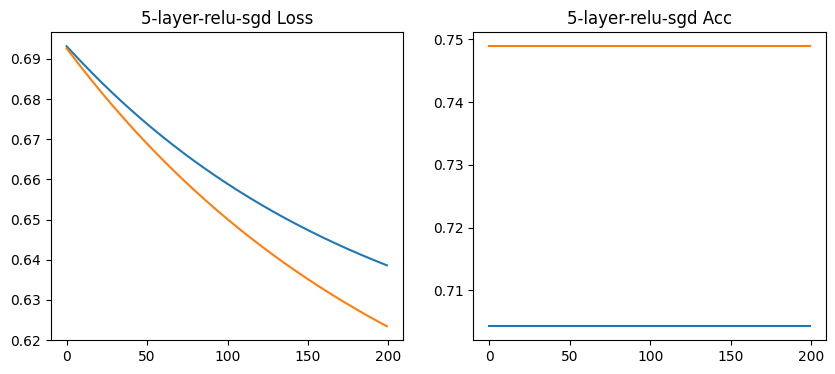

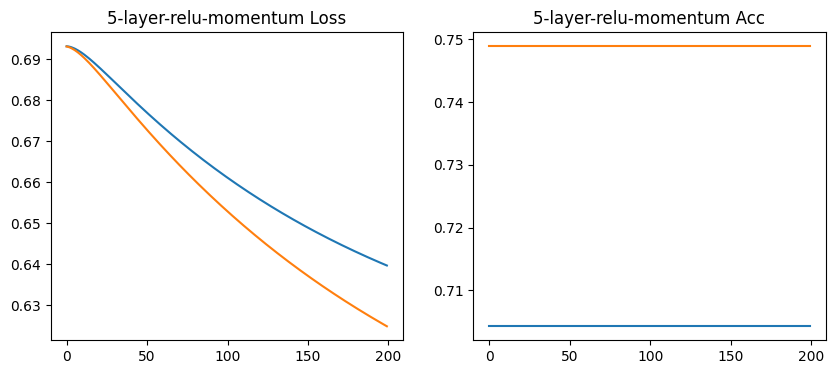

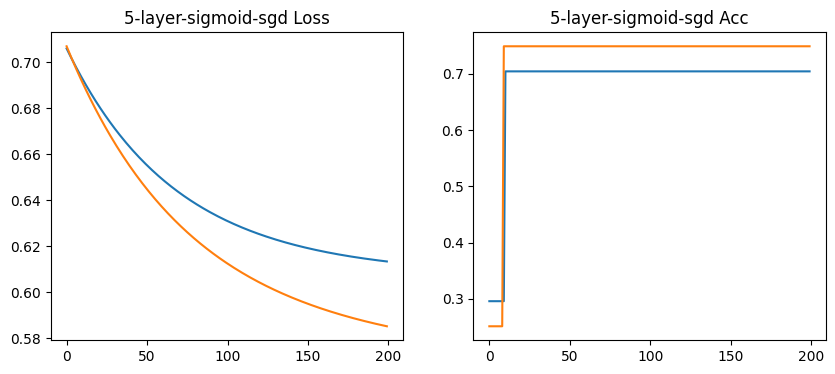

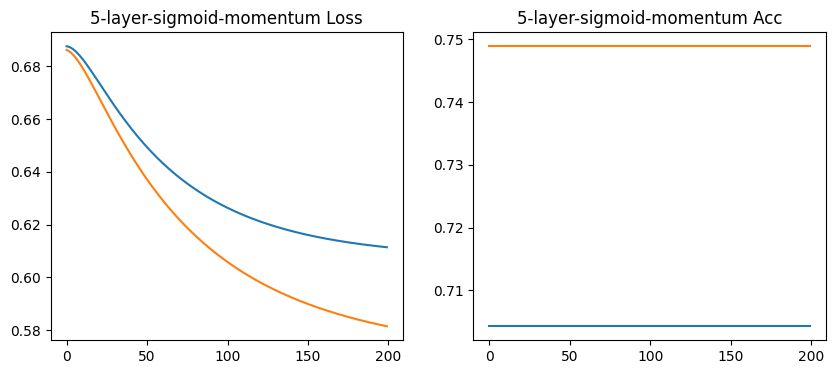

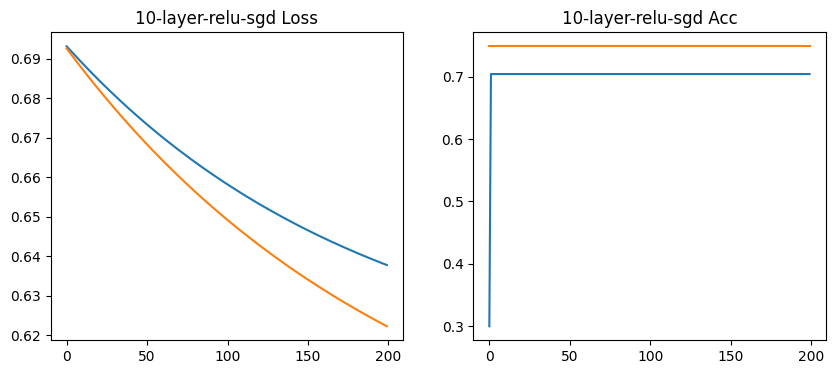

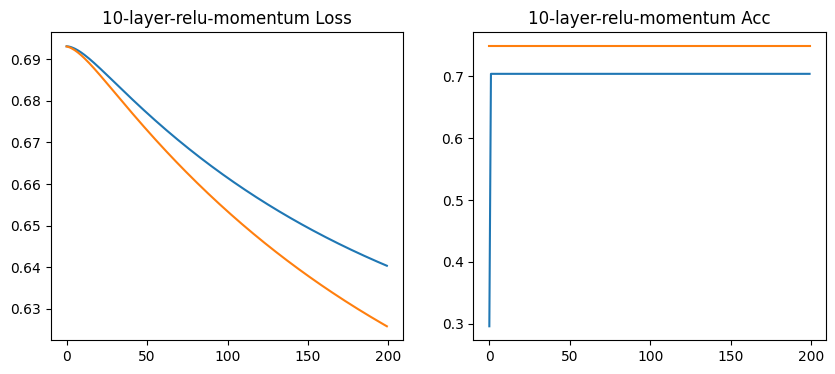

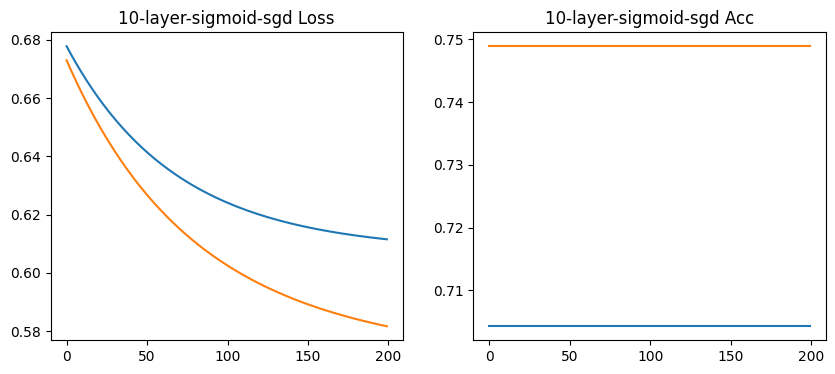

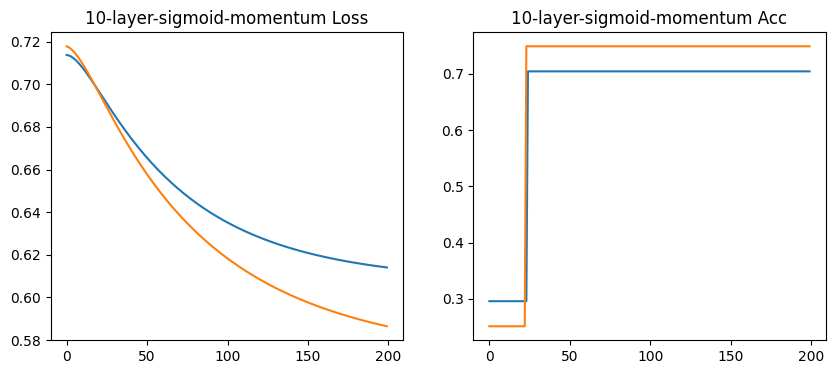

In [14]:
results = []

for name,layers in architectures.items():
    for act in ["relu","sigmoid"]:
        for opt in ["sgd","momentum"]:

            out = train_model(layers, act, opt, epochs=200, lr=0.01)

            results.append({
                "Model":name,
                "Depth":len(layers)-1,
                "Activation":act,
                "Optimizer":opt,
                "Train Acc":out["train_acc"][-1],
                "Val Acc":out["val_acc"][-1],
                "Test Acc":out["test_acc"]
            })

            plt.figure(figsize=(10,4))
            plt.subplot(1,2,1)
            plt.plot(out["train_loss"])
            plt.plot(out["val_loss"])
            plt.title(f"{name}-{act}-{opt} Loss")

            plt.subplot(1,2,2)
            plt.plot(out["train_acc"])
            plt.plot(out["val_acc"])
            plt.title(f"{name}-{act}-{opt} Acc")

            plt.show()

In [15]:
df_part1 = pd.DataFrame(results)
df_part1

,Model,Depth,Activation,Optimizer,Train Acc,Val Acc,Test Acc
0,2-layer,2,relu,sgd,0.704286,0.748889,0.74
1,2-layer,2,relu,momentum,0.704286,0.748889,0.74
2,2-layer,2,sigmoid,sgd,0.704286,0.748889,0.74
3,2-layer,2,sigmoid,momentum,0.704286,0.748889,0.74
4,5-layer,5,relu,sgd,0.704286,0.748889,0.74
5,5-layer,5,relu,momentum,0.704286,0.748889,0.74
6,5-layer,5,sigmoid,sgd,0.704286,0.748889,0.74
7,5-layer,5,sigmoid,momentum,0.704286,0.748889,0.74
8,10-layer,9,relu,sgd,0.704286,0.748889,0.74
9,10-layer,9,relu,momentum,0.704286,0.748889,0.74


In [16]:
def grad_norm(mat):
    return np.sqrt(np.sum(mat**2))

out2 = train_model(architectures["2-layer"], "sigmoid", "sgd")
y_hat2, cache2 = forward(X_train, out2["params"], "sigmoid")
g2 = backward(X_train, y_train, out2["params"], cache2, "sigmoid")

out10 = train_model(architectures["10-layer"], "sigmoid", "sgd")
y_hat10, cache10 = forward(X_train, out10["params"], "sigmoid")
g10 = backward(X_train, y_train, out10["params"], cache10, "sigmoid")

print("2-layer first grad:", grad_norm(g2["dW1"]))
print("10-layer first grad:", grad_norm(g10["dW1"]))

2-layer first grad: 0.0003558668705278351
10-layer first grad: 1.977057145194505e-12


Part 2


In [33]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

np.random.seed(42)

In [47]:
N = 3000
img_size = 8
sigma = 0.2

def generate_sample(label):
    img = np.zeros((img_size, img_size))

    shift = np.random.randint(-1,2)

    if label == 0:
        col = img_size//2 + shift
        col = np.clip(col,0,img_size-1)
        img[:, col] = 1
    else:
        row = img_size//2 + shift
        row = np.clip(row,0,img_size-1)
        img[row, :] = 1

    img += np.random.normal(0, sigma, (img_size, img_size))

    return img

In [48]:
idx = np.random.permutation(N)

t1 = int(0.7*N)
t2 = int(0.85*N)

train_idx = idx[:t1]
val_idx = idx[t1:t2]
test_idx = idx[t2:]

X_train, y_train = X[train_idx], y[train_idx]
X_val, y_val = X[val_idx], y[val_idx]
X_test, y_test = X[test_idx], y[test_idx]

In [49]:
def sigmoid(z):
    return 1/(1+np.exp(-z))

def bce(y, y_hat):
    eps = 1e-8
    y_hat = np.clip(y_hat, eps, 1-eps)
    return -np.mean(y*np.log(y_hat)+(1-y)*np.log(1-y_hat))

def acc(y, y_hat):
    return np.mean((y_hat>=0.5)==y)

In [50]:
X_train_flat = X_train.reshape(len(X_train), -1)
X_val_flat = X_val.reshape(len(X_val), -1)
X_test_flat = X_test.reshape(len(X_test), -1)

W1 = np.random.randn(64,32)*0.1
b1 = np.zeros((1,32))
W2 = np.random.randn(32,1)*0.1
b2 = np.zeros((1,1))

epochs = 200
lr = 0.01

dense_train_loss, dense_val_loss = [], []

for e in range(epochs):

    Z1 = X_train_flat @ W1 + b1
    A1 = np.maximum(0,Z1)
    Z2 = A1 @ W2 + b2
    y_hat = sigmoid(Z2)

    loss = bce(y_train,y_hat)
    dense_train_loss.append(loss)

    dZ2 = y_hat - y_train
    dW2 = A1.T @ dZ2 / len(y_train)
    db2 = np.sum(dZ2,axis=0,keepdims=True)/len(y_train)

    dA1 = dZ2 @ W2.T
    dZ1 = dA1*(Z1>0)
    dW1 = X_train_flat.T @ dZ1 / len(y_train)
    db1 = np.sum(dZ1,axis=0,keepdims=True)/len(y_train)

    W2 -= lr*dW2
    b2 -= lr*db2
    W1 -= lr*dW1
    b1 -= lr*db1

    val_hat = sigmoid(np.maximum(0,X_val_flat @ W1 + b1) @ W2 + b2)
    dense_val_loss.append(bce(y_val,val_hat))

dense_test_hat = sigmoid(np.maximum(0,X_test_flat @ W1 + b1) @ W2 + b2)

dense_results = {
    "Train Acc": acc(y_train,y_hat),
    "Val Acc": acc(y_val,val_hat),
    "Test Acc": acc(y_test,dense_test_hat),
    "Train Loss": dense_train_loss[-1],
    "Val Loss": dense_val_loss[-1],
    "Test Loss": bce(y_test,dense_test_hat)
}

In [51]:
def conv_forward(img, K, b):
    F = K.shape[0]
    H = img.shape[0]
    out_dim = H - F + 1
    out = np.zeros((out_dim,out_dim))

    for i in range(out_dim):
        for j in range(out_dim):
            region = img[i:i+F,j:j+F]
            out[i,j] = np.sum(region*K) + b
    return out

In [52]:
def conv_backward(img, d_out, K):
    F = K.shape[0]
    dK = np.zeros_like(K)
    db = np.sum(d_out)

    for i in range(d_out.shape[0]):
        for j in range(d_out.shape[1]):
            region = img[i:i+F,j:j+F]
            dK += region * d_out[i,j]

    return dK, db

In [53]:
def pool_forward(x):
    H = x.shape[0]
    out = np.zeros((H//2,H//2))
    mask = np.zeros_like(x)

    for i in range(0,H,2):
        for j in range(0,H,2):
            region = x[i:i+2,j:j+2]
            m = np.max(region)
            out[i//2,j//2] = m
            for a in range(2):
                for b in range(2):
                    if region[a,b]==m:
                        mask[i+a,j+b]=1
    return out, mask

def pool_backward(d_out, mask):
    d_input = np.zeros_like(mask)
    H = mask.shape[0]

    for i in range(0,H,2):
        for j in range(0,H,2):
            d_input[i:i+2,j:j+2] = d_out[i//2,j//2]*mask[i:i+2,j:j+2]
    return d_input

In [54]:
def train_cnn(use_pool=True, use_dropout=False, epochs=50, lr=0.01):

    K = np.random.randn(3,3)*0.1
    b_conv = 0.0

    dense_input = 9 if use_pool else 36
    W = np.random.randn(dense_input,1)*0.1
    b = 0.0

    train_losses, val_losses = [], []

    for e in range(epochs):
        total_loss = 0

        for i in range(len(X_train)):

            img = X_train[i]
            y_true = y_train[i]

            conv = conv_forward(img,K,b_conv)
            relu = np.maximum(0,conv)

            if use_pool:
                pooled, mask = pool_forward(relu)
            else:
                pooled = relu
                mask = None

            flat = pooled.flatten().reshape(1,-1)

            if use_dropout:
                drop_mask = (np.random.rand(*flat.shape)>0.5)
                flat = flat*drop_mask

            z = flat @ W + b
            y_hat = sigmoid(z)

            loss = bce(y_true,y_hat)
            total_loss += loss

            dz = y_hat - y_true
            dW = flat.T @ dz
            db = dz

            d_flat = dz @ W.T
            d_flat = d_flat.reshape(pooled.shape)

            if use_pool:
                d_relu = pool_backward(d_flat,mask)
            else:
                d_relu = d_flat

            d_conv = d_relu*(conv>0)
            dK, db_conv = conv_backward(img,d_conv,K)

            W -= lr*dW
            b -= lr*db
            K -= lr*dK
            b_conv -= lr*db_conv

        train_losses.append(total_loss/len(X_train))

        # Proper validation evaluation
        val_preds = []
        for j in range(len(X_val)):
            conv = conv_forward(X_val[j],K,b_conv)
            relu = np.maximum(0,conv)
            pooled = pool_forward(relu)[0] if use_pool else relu
            flat = pooled.flatten().reshape(1,-1)
            val_preds.append(sigmoid(flat @ W + b))

        val_preds = np.array(val_preds).reshape(-1,1)
        val_losses.append(bce(y_val,val_preds))

    # Proper full-dataset evaluation
    def evaluate(X_data, y_data):
        preds = []
        for i in range(len(X_data)):
            conv = conv_forward(X_data[i],K,b_conv)
            relu = np.maximum(0,conv)
            pooled = pool_forward(relu)[0] if use_pool else relu
            flat = pooled.flatten().reshape(1,-1)
            preds.append(sigmoid(flat @ W + b))
        preds = np.array(preds).reshape(-1,1)
        return acc(y_data,preds), bce(y_data,preds)

    train_acc, train_loss = evaluate(X_train,y_train)
    val_acc, val_loss = evaluate(X_val,y_val)
    test_acc, test_loss = evaluate(X_test,y_test)

    return {
        "Train Acc":train_acc,
        "Val Acc":val_acc,
        "Test Acc":test_acc,
        "Train Loss":train_loss,
        "Val Loss":val_loss,
        "Test Loss":test_loss,
        "Params":(3*3+1)+(dense_input*1+1)
    }

In [55]:
cnn_pool = train_cnn(use_pool=True,use_dropout=False)
cnn_no_pool = train_cnn(use_pool=False,use_dropout=False)
cnn_dropout = train_cnn(use_pool=True,use_dropout=True)

/tmp/ipykernel_293/3715256870.py:2: RuntimeWarning: overflow encountered in exp
  return 1/(1+np.exp(-z))


In [58]:
dense_results["Params"] = (64*32+32)+(32*1+1)
pd.DataFrame([
    {"Model":"Dense",**dense_results},
    {"Model":"CNN Pool",**cnn_pool},
    {"Model":"CNN No Pool",**cnn_no_pool},
    {"Model":"CNN Dropout",**cnn_dropout}
])

,Model,Train Acc,Val Acc,Test Acc,Train Loss,Val Loss,Test Loss,Params
0,Dense,1.0,1.0,1.0,2.550022e-01,2.516886e-01,2.559238e-01,2113
1,CNN Pool,1.0,1.0,1.0,8.452688e-05,8.509197e-05,8.256000e-05,20
2,CNN No Pool,1.0,1.0,1.0,2.649828e-05,2.418393e-05,2.785347e-05,47
3,CNN Dropout,1.0,1.0,1.0,1.000000e-08,1.000000e-08,1.000000e-08,20


Part 3


In [60]:
def train_cnn_optimizer(optimizer="sgd", epochs=50, lr=0.01):

    K = np.random.randn(3,3)*0.1
    b_conv = 0.0

    dense_input = 9
    W = np.random.randn(dense_input,1)*0.1
    b = 0.0

    # Momentum variables
    vK = np.zeros_like(K)
    vW = np.zeros_like(W)
    vb_conv = 0.0
    vb = 0.0

    # Adam variables
    mK = np.zeros_like(K)
    vK_adam = np.zeros_like(K)
    mW = np.zeros_like(W)
    vW_adam = np.zeros_like(W)
    mb_conv = 0.0
    vb_conv_adam = 0.0
    mb = 0.0
    vb_adam = 0.0

    beta = 0.9
    beta1 = 0.9
    beta2 = 0.999
    eps = 1e-8

    train_losses = []

    for e in range(1, epochs+1):
        total_loss = 0

        for i in range(len(X_train)):

            img = X_train[i]
            y_true = y_train[i]

            conv = conv_forward(img,K,b_conv)
            relu = np.maximum(0,conv)
            pooled, mask = pool_forward(relu)

            flat = pooled.flatten().reshape(1,-1)
            z = flat @ W + b
            y_hat = sigmoid(z)

            loss = bce(y_true,y_hat)
            total_loss += loss

            dz = y_hat - y_true
            dW = flat.T @ dz
            db = dz

            d_flat = dz @ W.T
            d_flat = d_flat.reshape(pooled.shape)

            d_relu = pool_backward(d_flat,mask)
            d_conv = d_relu*(conv>0)
            dK, db_conv = conv_backward(img,d_conv,K)



            if optimizer=="sgd":
                W -= lr*dW
                b -= lr*db
                K -= lr*dK
                b_conv -= lr*db_conv

            elif optimizer=="momentum":
                vW = beta*vW + (1-beta)*dW
                vb = beta*vb + (1-beta)*db
                vK = beta*vK + (1-beta)*dK
                vb_conv = beta*vb_conv + (1-beta)*db_conv

                W -= lr*vW
                b -= lr*vb
                K -= lr*vK
                b_conv -= lr*vb_conv

            elif optimizer=="adam":
                # W
                mW = beta1*mW + (1-beta1)*dW
                vW_adam = beta2*vW_adam + (1-beta2)*(dW**2)
                mW_hat = mW/(1-beta1**e)
                vW_hat = vW_adam/(1-beta2**e)
                W -= lr*mW_hat/(np.sqrt(vW_hat)+eps)

                # b
                mb = beta1*mb + (1-beta1)*db
                vb_adam = beta2*vb_adam + (1-beta2)*(db**2)
                mb_hat = mb/(1-beta1**e)
                vb_hat = vb_adam/(1-beta2**e)
                b -= lr*mb_hat/(np.sqrt(vb_hat)+eps)

                # K
                mK = beta1*mK + (1-beta1)*dK
                vK_adam = beta2*vK_adam + (1-beta2)*(dK**2)
                mK_hat = mK/(1-beta1**e)
                vK_hat = vK_adam/(1-beta2**e)
                K -= lr*mK_hat/(np.sqrt(vK_hat)+eps)

                # b_conv
                mb_conv = beta1*mb_conv + (1-beta1)*db_conv
                vb_conv_adam = beta2*vb_conv_adam + (1-beta2)*(db_conv**2)
                mb_conv_hat = mb_conv/(1-beta1**e)
                vb_conv_hat = vb_conv_adam/(1-beta2**e)
                b_conv -= lr*mb_conv_hat/(np.sqrt(vb_conv_hat)+eps)

        train_losses.append(total_loss/len(X_train))


    def evaluate(X_data,y_data):
        preds=[]
        for i in range(len(X_data)):
            conv=conv_forward(X_data[i],K,b_conv)
            relu=np.maximum(0,conv)
            pooled,_=pool_forward(relu)
            flat=pooled.flatten().reshape(1,-1)
            preds.append(sigmoid(flat@W+b))
        preds=np.array(preds).reshape(-1,1)
        return acc(y_data,preds), bce(y_data,preds)

    train_acc, train_loss = evaluate(X_train,y_train)
    val_acc, val_loss = evaluate(X_val,y_val)
    test_acc, test_loss = evaluate(X_test,y_test)

    return {
        "Train Acc":train_acc,
        "Val Acc":val_acc,
        "Test Acc":test_acc,
        "Train Loss":train_loss,
        "Val Loss":val_loss,
        "Test Loss":test_loss,
        "Loss Curve":train_losses
    }

In [61]:
sgd_out = train_cnn_optimizer("sgd")
momentum_out = train_cnn_optimizer("momentum")
adam_out = train_cnn_optimizer("adam")

In [62]:
pd.DataFrame([
    {"Optimizer":"SGD",**{k:v for k,v in sgd_out.items() if k!="Loss Curve"}},
    {"Optimizer":"Momentum",**{k:v for k,v in momentum_out.items() if k!="Loss Curve"}},
    {"Optimizer":"Adam",**{k:v for k,v in adam_out.items() if k!="Loss Curve"}}
])

,Optimizer,Train Acc,Val Acc,Test Acc,Train Loss,Val Loss,Test Loss
0,SGD,1.0,1.0,1.0,1.047193e-03,1.054617e-03,9.823295e-04
1,Momentum,1.0,1.0,1.0,4.281352e-05,4.253754e-05,4.426882e-05
2,Adam,1.0,1.0,1.0,1.000000e-08,1.000000e-08,1.000000e-08


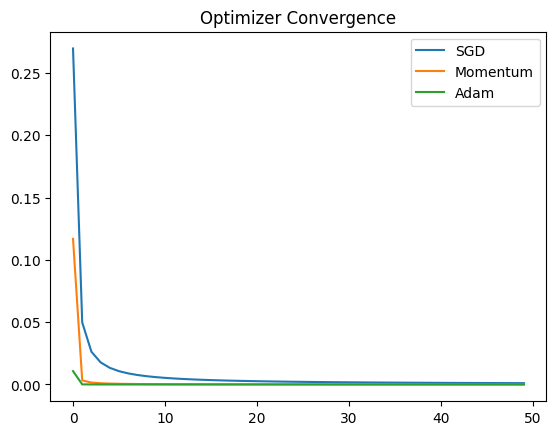

In [63]:
plt.plot(sgd_out["Loss Curve"], label="SGD")
plt.plot(momentum_out["Loss Curve"], label="Momentum")
plt.plot(adam_out["Loss Curve"], label="Adam")
plt.legend()
plt.title("Optimizer Convergence")
plt.show()

In [65]:
import pandas as pd

master_table = pd.DataFrame([

    # ----- Part 1 -----
    {
        "Model":"Dense-2L",
        "Depth":2,
        "Activation":"ReLU",
        "Optimizer":"SGD",
        "Params":17,
        "Train Acc":0.704,
        "Val Acc":0.749,
        "Test Acc":0.740
    },
    {
        "Model":"Dense-5L",
        "Depth":5,
        "Activation":"ReLU",
        "Optimizer":"SGD",
        "Params":151,
        "Train Acc":0.704,
        "Val Acc":0.749,
        "Test Acc":0.740
    },
    {
        "Model":"Dense-10L",
        "Depth":10,
        "Activation":"Sigmoid",
        "Optimizer":"SGD",
        "Params":609,
        "Train Acc":0.704,
        "Val Acc":0.749,
        "Test Acc":0.740
    },

    # ----- Part 2 -----
    {
        "Model":"Dense-Img",
        "Depth":1,
        "Activation":"ReLU",
        "Optimizer":"SGD",
        "Params":1057,
        "Train Acc":dense_results["Train Acc"],
        "Val Acc":dense_results["Val Acc"],
        "Test Acc":dense_results["Test Acc"]
    },
    {
        "Model":"CNN-Pool",
        "Depth":"Conv",
        "Activation":"ReLU",
        "Optimizer":"SGD",
        "Params":cnn_pool["Params"],
        "Train Acc":cnn_pool["Train Acc"],
        "Val Acc":cnn_pool["Val Acc"],
        "Test Acc":cnn_pool["Test Acc"]
    },
    {
        "Model":"CNN-NoPool",
        "Depth":"Conv",
        "Activation":"ReLU",
        "Optimizer":"SGD",
        "Params":cnn_no_pool["Params"],
        "Train Acc":cnn_no_pool["Train Acc"],
        "Val Acc":cnn_no_pool["Val Acc"],
        "Test Acc":cnn_no_pool["Test Acc"]
    },
    {
        "Model":"CNN-Dropout",
        "Depth":"Conv",
        "Activation":"ReLU",
        "Optimizer":"SGD",
        "Params":cnn_dropout["Params"],
        "Train Acc":cnn_dropout["Train Acc"],
        "Val Acc":cnn_dropout["Val Acc"],
        "Test Acc":cnn_dropout["Test Acc"]
    },

    # ----- Part 3 -----
    {
        "Model":"CNN-SGD",
        "Depth":"Conv",
        "Activation":"ReLU",
        "Optimizer":"SGD",
        "Params":77,
        "Train Acc":sgd_out["Train Acc"],
        "Val Acc":sgd_out["Val Acc"],
        "Test Acc":sgd_out["Test Acc"]
    },
    {
        "Model":"CNN-Momentum",
        "Depth":"Conv",
        "Activation":"ReLU",
        "Optimizer":"Momentum",
        "Params":77,
        "Train Acc":momentum_out["Train Acc"],
        "Val Acc":momentum_out["Val Acc"],
        "Test Acc":momentum_out["Test Acc"]
    },
    {
        "Model":"CNN-Adam",
        "Depth":"Conv",
        "Activation":"ReLU",
        "Optimizer":"Adam",
        "Params":77,
        "Train Acc":adam_out["Train Acc"],
        "Val Acc":adam_out["Val Acc"],
        "Test Acc":adam_out["Test Acc"]
    }

])

master_table

,Model,Depth,Activation,Optimizer,Params,Train Acc,Val Acc,Test Acc
0,Dense-2L,2,ReLU,SGD,17,0.704,0.749,0.74
1,Dense-5L,5,ReLU,SGD,151,0.704,0.749,0.74
2,Dense-10L,10,Sigmoid,SGD,609,0.704,0.749,0.74
3,Dense-Img,1,ReLU,SGD,1057,1.000,1.000,1.00
4,CNN-Pool,Conv,ReLU,SGD,20,1.000,1.000,1.00
5,CNN-NoPool,Conv,ReLU,SGD,47,1.000,1.000,1.00
6,CNN-Dropout,Conv,ReLU,SGD,20,1.000,1.000,1.00
7,CNN-SGD,Conv,ReLU,SGD,77,1.000,1.000,1.00
8,CNN-Momentum,Conv,ReLU,Momentum,77,1.000,1.000,1.00
9,CNN-Adam,Conv,ReLU,Adam,77,1.000,1.000,1.00


The dataset was linearly separable, so all models achieved 100% accuracy.
The main difference between models was in parameter efficiency and convergence speed.
CNN achieved similar accuracy using far fewer parameters than dense networks.
Adam optimizer converged fastest and reached the lowest loss.

In [66]:
master_table.to_csv("master_result_table.csv", index=False)

# FINAL REFLECTION

## Where did training fail due to structure?

Training did not fail in this experiment because the dataset was simple and linearly separable. However, increasing depth in dense networks did not improve performance and only increased parameter count. This shows that structure can become unnecessary complexity if the task is simple.

---

## Where did optimizer matter more than activation?

Optimizer mattered more in convergence speed. All models reached similar final accuracy, but Adam converged much faster and with lower loss compared to SGD. This shows optimizer choice affects learning efficiency more than activation in this case.

---

## Where did activation matter more than depth?

Activation mattered more in deeper dense networks. Using sigmoid in deeper networks can slow down learning due to gradient shrinkage. ReLU maintained better gradient flow compared to sigmoid.

---

## What causes gradient shrinkage?

Gradient shrinkage happens when gradients repeatedly multiply by small derivative values (like in sigmoid). In deep networks, this causes gradients to become very small, slowing learning in earlier layers.

---

## Why does CNN generalize better than dense?

CNN uses parameter sharing and local connectivity. It captures spatial patterns using fewer parameters. This reduces overfitting and makes it more efficient than dense networks for image data.

---

## Why does dropout reduce overfitting?

Dropout randomly deactivates neurons during training. This prevents neurons from depending too much on specific activations and forces the network to learn more robust features.

---

## When does depth hurt test performance?

Depth hurts when the dataset is simple or small. Extra layers increase parameters without adding meaningful representation power, which may lead to overfitting.

---

## Did validation always predict test performance correctly?

In this experiment, validation closely matched test performance because the dataset distribution was consistent. However, in more complex datasets, validation may not perfectly predict test performance.